# Phase 1 EDA

This notebook covers problem definition, dataset overview, EDA plots, and baseline planning.

In [1]:
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'src' / 'spotify_ml').exists():
            return p
    raise RuntimeError('Could not find project root (expected src/spotify_ml).')

ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(ROOT / 'src'))
print('Project root:', ROOT)


Project root: C:\Users\K.Shokraneh\Projs\ML\Spotify


## Imports and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from spotify_ml.features.core import add_is_sonnati_label

DATA_PATH = str(ROOT / 'data' / 'raw' / 'Spotfiy_Persian_Artists.csv')

df = pd.read_csv(DATA_PATH)
df = add_is_sonnati_label(df)

df.head()

,track_id,disc_number,duration_ms,explicit,track_name,track_name_farsi,artist_name,artist_name_farsi,popularity,track_number,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,key_name,mode_name,key_mode,is_sonnati
0,31iPeC6I0AiRW8InOxNKzm,1,446880,False,Ghazale Taze,NaN,Salar Aghili,سالار عقیلی,NaN,1,...,0.839,0.000035,0.1360,0.330,131.913,3,C,minor,C minor,1
1,4Fi46ha8teWYTwk0b8fNPi,1,851920,False,Ayeeneye Hosn,NaN,Salar Aghili,سالار عقیلی,NaN,2,...,0.970,0.000360,0.0812,0.346,105.634,4,F,major,F major,1
2,0lQAe6EslKA7CUsS7SCW6Q,1,293160,False,Tarke Eshgh,NaN,Salar Aghili,سالار عقیلی,NaN,3,...,0.664,0.002070,0.1100,0.501,94.651,5,F,minor,F minor,1
3,6dAFmJdVsKk5ksCpGqnKgO,1,648720,False,Moghbacheye Bade Foroosh,NaN,Salar Aghili,سالار عقیلی,NaN,4,...,0.915,0.006580,0.2120,0.445,110.967,5,D,minor,D minor,1
4,4VSDJGyEdSMB8UL4fDSCvv,1,273480,False,Bigharar,NaN,Salar Aghili,سالار عقیلی,NaN,5,...,0.657,0.000008,0.1200,0.410,148.053,1,C,minor,C minor,1


## Dataset Overview

In [3]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

df.describe(include='all').transpose().head()

Shape: (10632, 33)
Columns: ['track_id', 'disc_number', 'duration_ms', 'explicit', 'track_name', 'track_name_farsi', 'artist_name', 'artist_name_farsi', 'popularity', 'track_number', 'album_href', 'album_id', 'album_name', 'album_release_date', 'album_total_tracks', 'album_release_year', 'track_href', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'key_name', 'mode_name', 'key_mode', 'is_sonnati']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,10632,10277,7AfjNb1GsCHy7aAHyp1O0h,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
disc_number,10632.0,NaN,NaN,NaN,1.069225,0.386374,1.0,1.0,1.0,1.0,4.0
duration_ms,10632.0,NaN,NaN,NaN,288801.107129,169521.984026,3996.0,203569.0,253618.0,333774.5,3978450.0
explicit,10632,2,False,10611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,10632,7586,Chaharmezrab,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Values

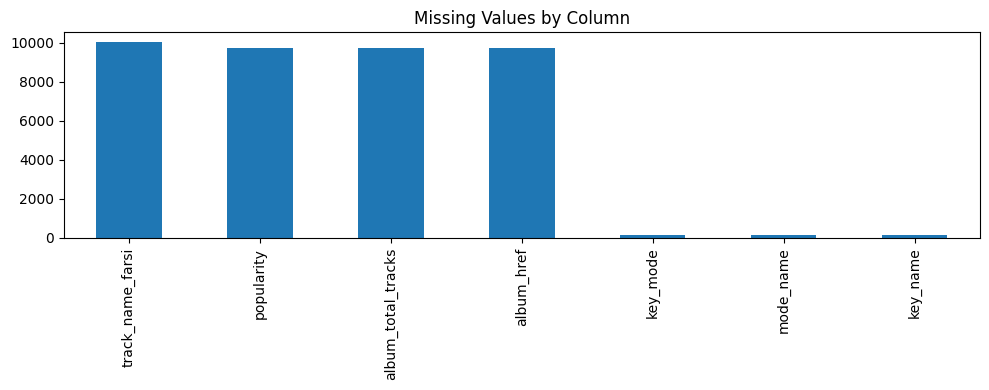

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
plt.figure(figsize=(10,4))
missing[missing>0].plot(kind='bar')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.show()

## Popularity Distribution

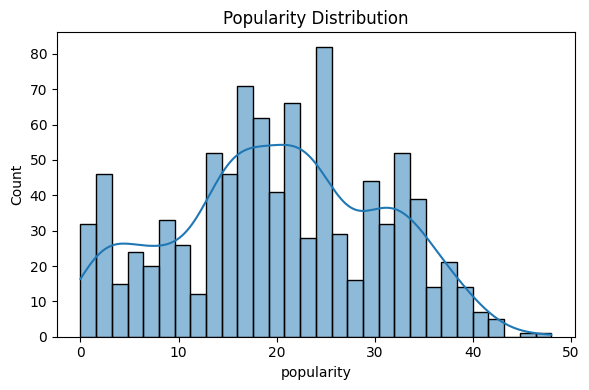

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df['popularity'].dropna(), bins=30, kde=True)
plt.title('Popularity Distribution')
plt.tight_layout()
plt.show()

## Correlation Heatmap

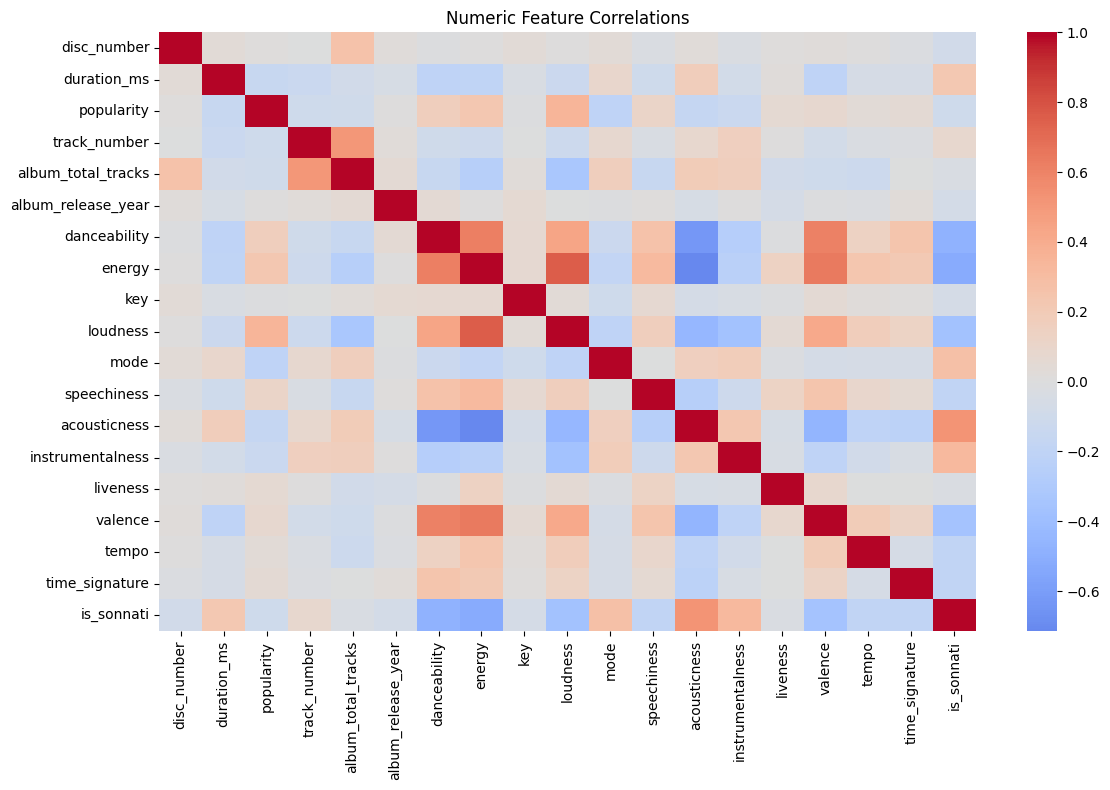

In [6]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Numeric Feature Correlations')
plt.tight_layout()
plt.show()

## Top Artists by Popularity

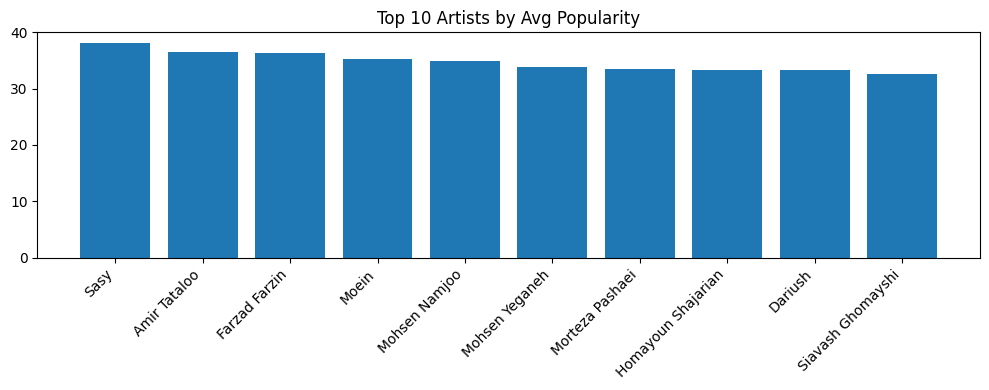

In [7]:
top_artists = df.groupby('artist_name')['popularity'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,4))
plt.bar(top_artists.index, top_artists.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Artists by Avg Popularity')
plt.tight_layout()
plt.show()

## Feature Trends by Release Year

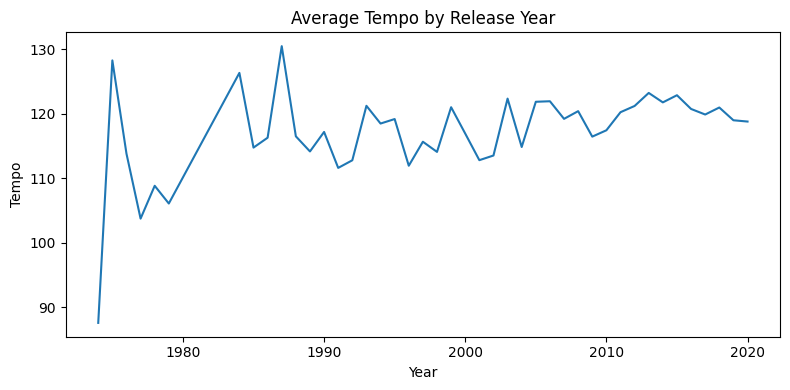

In [8]:
df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')
trend = df.groupby(df['album_release_date'].dt.year)['tempo'].mean()
plt.figure(figsize=(8,4))
plt.plot(trend.index, trend.values)
plt.title('Average Tempo by Release Year')
plt.xlabel('Year')
plt.ylabel('Tempo')
plt.tight_layout()
plt.show()

## Class Balance for is_sonnati

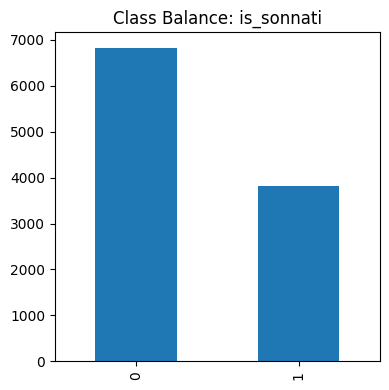

In [9]:
class_counts = df['is_sonnati'].value_counts()
plt.figure(figsize=(4,4))
class_counts.plot(kind='bar')
plt.title('Class Balance: is_sonnati')
plt.tight_layout()
plt.show()

## Baseline Plan

- Regression: Ridge Regression
- Classification: Logistic Regression (class-weighted)
- Metrics: MAE/RMSE/R2 for regression; Accuracy/F1/ROC-AUC for classification